# Tutorial 00: Setup & Quick Start

**Workshop: ML for Galactic Binary Search & Parameter Estimation**

---

## Goals (~15 minutes)

1. Load the pre-trained SlotFlow model
2. Run inference on one example
3. Understand what SlotFlow does and doesn't do
4. **Critically**: Understand the toy model vs real LISA GBs

---

## Important: SlotFlow is a Proof-of-Concept

Before we start, let's be clear about what SlotFlow demonstrates:

| Aspect | SlotFlow (Toy) | Real LISA GBs |
|--------|---------------|---------------|
| **Frequency range** | 2.5–3.0 Hz | 0.1–30 mHz |
| **Parameters/source** | 3 (A, φ, f) | 7–8 (f, ḟ, A, ι, ψ, φ₀, λ, β) |
| **Observation time** | 300 s | 4+ years |
| **Number of sources** | 1–10 | ~10,000 resolvable |
| **Instrument response** | None | TDI |

**The methods transfer; the specific numbers don't.**

SlotFlow demonstrates:
- Trans-dimensional inference (learning K)
- Permutation-invariant posteriors
- Amortized inference with normalizing flows

These concepts apply directly to LISA — but a production system would need retraining on realistic data.

In [1]:
# ================================================================
# Setup
# ================================================================
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from src.dataset import MultiSinusoidDataset, custom_collate
from src.model import SlotFlow

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [2]:
# ================================================================
# Load Pre-trained Model
# ================================================================

# Paths
config_path = "../pretrained_model/test_clariden/model_config.pt"
ckpt_dir = "../pretrained_model/test_clariden/checkpoints"

# Load config
config = torch.load(config_path, map_location="cpu")

# Key parameters we'll need throughout
FREQ_RANGE = config["freq_range"]      # (2.5, 3.0) Hz
AMP_RANGE = config["amp_range"]        # (0.5, 1.5)
NOISE_STD = config["noise_std"]        # (0, 1.5)
MAX_K = config["max_slots"]            # 10
T_LONG = config["tEnd_long"]           # 300 s
T_SHORT = config["tEnd_short"]         # 10 s

print("SlotFlow training configuration:")
print(f"  Frequency range: {FREQ_RANGE} Hz")
print(f"  Max sources (K): {MAX_K}")
print(f"  Observation: {T_LONG}s (long) + {T_SHORT}s (short)")

SlotFlow training configuration:
  Frequency range: (2.5, 3) Hz
  Max sources (K): 10
  Observation: 300s (long) + 10s (short)


/var/folders/sr/n2fcp1f90810jp4b_lrryl700000gn/T/ipykernel_25657/843065722.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  config = torch.load(config_path, map_location

In [3]:
# ================================================================
# Initialize and Load Model
# ================================================================

# Find checkpoint
ckpt_files = [f for f in os.listdir(ckpt_dir) if "best" in f and f.endswith(".ckpt")]
if not ckpt_files:
    ckpt_files = [f for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")]
ckpt_path = os.path.join(ckpt_dir, sorted(ckpt_files)[-1])

# Load checkpoint
ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = {k.replace("model.", "").replace("_orig_mod.", ""): v 
              for k, v in ckpt["state_dict"].items()}

# Create model
model = SlotFlow(
    hidden_dim=config["hidden_dim"],
    max_slots=config["max_slots"],
    flow_depth=config.get("flow_depth", 8),
    use_noise_encoder=config.get("use_noise_encoder", False),
)
model.load_state_dict(state_dict, strict=True)
model.to(device).eval()

print(f"\nModel loaded from epoch {ckpt.get('epoch', '?')}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

/var/folders/sr/n2fcp1f90810jp4b_lrryl700000gn/T/ipykernel_25657/1723350653.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="c


Model loaded from epoch 184
Total parameters: 31,313,626


In [4]:
# ================================================================
# Create a Test Signal
# ================================================================

# Create small test dataset
test_set = MultiSinusoidDataset(
    set_size=100,
    num_samples_long=config["num_samples_long"],
    tEnd_long=T_LONG,
    num_samples_short=config["num_samples_short"],
    tEnd_short=T_SHORT,
    max_components=MAX_K,
    freq_range=FREQ_RANGE,
    amp_range=AMP_RANGE,
    noise_std=NOISE_STD,
    min_freq_sep=0.01,
    seed=42,
    mode="inference",
)

# Get one sample
idx = 10  # Arbitrary choice
x_long, x_short, true_k, _, true_params, noise_std, _ = test_set[idx]

print(f"Sample {idx}:")
print(f"  True K = {true_k}")
print(f"  Noise σ = {noise_std:.2f}")
print(f"\n  True parameters:")
for i in range(true_k):
    A, phi, f = true_params[i].tolist()
    print(f"    Source {i+1}: A={A:.2f}, φ={phi:.2f} rad, f={f:.4f} Hz")

Sample 10:
  True K = 10
  Noise σ = 0.86

  True parameters:
    Source 1: A=1.43, φ=5.21 rad, f=2.8919 Hz
    Source 2: A=0.81, φ=1.57 rad, f=2.8431 Hz
    Source 3: A=1.49, φ=5.83 rad, f=2.7204 Hz
    Source 4: A=0.83, φ=4.77 rad, f=2.9786 Hz
    Source 5: A=0.91, φ=5.12 rad, f=2.6580 Hz
    Source 6: A=1.15, φ=1.34 rad, f=2.9641 Hz
    Source 7: A=1.46, φ=2.13 rad, f=2.5804 Hz
    Source 8: A=1.32, φ=0.23 rad, f=2.8073 Hz
    Source 9: A=1.28, φ=0.52 rad, f=2.8768 Hz
    Source 10: A=1.14, φ=2.09 rad, f=2.9983 Hz


In [5]:
# ================================================================
# Run Inference
# ================================================================

@torch.no_grad()
def run_slotflow(model, x_long, x_short, n_posterior_samples=2000):
    """
    Run SlotFlow inference and return structured results.
    """
    # Forward pass
    x_l = x_long.unsqueeze(0).to(device)
    x_s = x_short.unsqueeze(0).to(device)
    output = model(x_l, x_s)
    
    # Extract K prediction
    k_pred = output['K_pred'].item()
    k_probs = F.softmax(output['K_logits'], dim=-1).cpu().numpy().squeeze()
    
    # Sample posteriors for each slot
    context = output['context']
    posteriors = []
    freq_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
    
    for k in range(k_pred):
        samples = model.flow.sample(n_posterior_samples, context=context[k:k+1])
        samples = samples.squeeze(0).cpu()
        
        # Transform to physical parameters
        amp = samples[:, 0].numpy()
        phase = torch.atan2(samples[:, 2], samples[:, 1]).numpy() % (2*np.pi)
        freq = (samples[:, 3].numpy() / 3.0) + freq_center  # Undo normalization
        
        posteriors.append({'amp': amp, 'phase': phase, 'freq': freq})
    
    return {'k_pred': k_pred, 'k_probs': k_probs, 'posteriors': posteriors}

# Run it
results = run_slotflow(model, x_long, x_short)

print(f"Predicted K = {results['k_pred']} (true K = {true_k})")
print(f"\nK probabilities:")
for k in range(1, MAX_K + 1):
    bar = '█' * int(results['k_probs'][k-1] * 30)
    print(f"  K={k:2d}: {results['k_probs'][k-1]:.3f} {bar}")

Predicted K = 10 (true K = 10)

K probabilities:
  K= 1: 0.000 
  K= 2: 0.000 
  K= 3: 0.000 
  K= 4: 0.000 
  K= 5: 0.000 
  K= 6: 0.000 
  K= 7: 0.000 
  K= 8: 0.000 
  K= 9: 0.000 
  K=10: 1.000 ██████████████████████████████


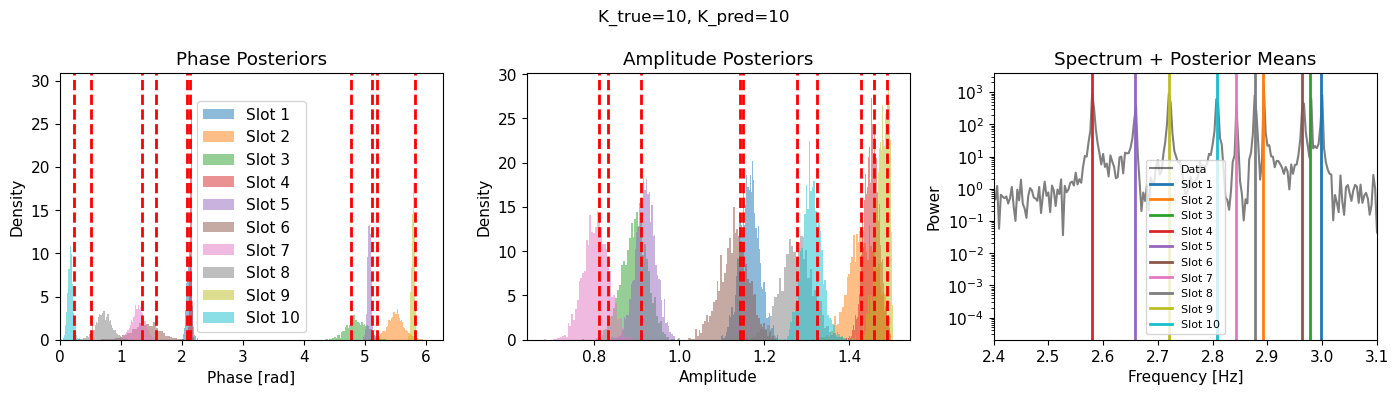

In [6]:
# ================================================================
# Visualize Results
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = plt.cm.tab10(np.linspace(0, 1, max(results['k_pred'], true_k)))

# 1. Phase posteriors
ax = axes[0]
for k, post in enumerate(results['posteriors']):
    ax.hist(post['phase'], bins=50, alpha=0.5, density=True, 
            color=colors[k], label=f'Slot {k+1}')
for k in range(true_k):
    ax.axvline(true_params[k, 1].item() % (2*np.pi), color='red', ls='--', lw=2)
ax.set_xlabel('Phase [rad]')
ax.set_ylabel('Density')
ax.set_title('Phase Posteriors')
ax.set_xlim(0, 2*np.pi)
ax.legend()

# 2. Amplitude posteriors
ax = axes[1]
for k, post in enumerate(results['posteriors']):
    ax.hist(post['amp'], bins=50, alpha=0.5, density=True, color=colors[k])
for k in range(true_k):
    ax.axvline(true_params[k, 0].item(), color='red', ls='--', lw=2)
ax.set_xlabel('Amplitude')
ax.set_ylabel('Density')
ax.set_title('Amplitude Posteriors')

# 3. Power spectrum with posteriors
ax = axes[2]
freqs = np.fft.rfftfreq(len(x_long), d=T_LONG/len(x_long))
power = np.abs(np.fft.rfft(x_long.numpy()))**2 / len(x_long)
ax.semilogy(freqs, power, 'k-', alpha=0.5, label='Data')

# Overlay posterior means
for k, post in enumerate(results['posteriors']):
    f_mean = np.mean(post['freq'])
    ax.axvline(f_mean, color=colors[k], ls='-', lw=2, label=f'Slot {k+1}')
ax.set_xlim(FREQ_RANGE[0]-0.1, FREQ_RANGE[1]+0.1)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Power')
ax.set_title('Spectrum + Posterior Means')
ax.legend(fontsize=8)

plt.suptitle(f'K_true={true_k}, K_pred={results["k_pred"]}', fontsize=12)
plt.tight_layout()
plt.show()

## Mapping to Real LISA Parameters

Here's how to think about translating SlotFlow's toy model to real GB inference:

In [7]:
# ================================================================
# Conceptual Mapping: Toy → LISA
# ================================================================

def print_mapping():
    print("="*70)
    print("CONCEPTUAL MAPPING: SlotFlow Toy Model → LISA GBs")
    print("="*70)
    print("""
    FREQUENCIES:
    ─────────────
    SlotFlow: 2.5–3.0 Hz (Δf = 0.5 Hz bandwidth)
    LISA GBs: 0.1–30 mHz (Δf = 30 mHz bandwidth)
    
    → Scale factor: ~100x in frequency
    → Rayleigh limit scales with 1/T_obs
    
    OBSERVATION TIME:
    ─────────────────
    SlotFlow: 300 s → Δf_Rayleigh = 3.3 mHz
    LISA 4yr: 1.26×10⁸ s → Δf_Rayleigh = 8 nHz
    
    → LISA resolves sources ~4×10⁵ times better!
    
    NUMBER OF SOURCES:
    ──────────────────
    SlotFlow: K = 1–10
    LISA: K ~ 10,000 resolvable (10⁷ total in band)
    
    → Need hierarchical/scalable approaches
    
    PARAMETERS:
    ───────────
    SlotFlow: 3 per source (A, φ, f)
    LISA GBs: 7–8 per source (f, ḟ, A, ι, ψ, φ₀, λ, β)
    
    → Need to add:
       • Frequency derivative ḟ (chirp)
       • Sky location (λ, β)
       • Polarization angle ψ
       • Inclination ι
    
    WHAT TRANSFERS DIRECTLY:
    ─────────────────────────
    ✓ Trans-dimensional inference (learning K)
    ✓ Slot-based architecture
    ✓ Hungarian matching for permutation invariance
    ✓ Normalizing flows for posterior estimation
    ✓ Dual-stream encoding (time + frequency domain)
    
    WHAT NEEDS ADAPTATION:
    ──────────────────────
    • Retrain on mHz frequencies with TDI response
    • Extend parameter space (3D → 8D per source)
    • Scale architecture for K ~ 10⁴
    • Handle confusion foreground
    """)

print_mapping()

CONCEPTUAL MAPPING: SlotFlow Toy Model → LISA GBs

    FREQUENCIES:
    ─────────────
    SlotFlow: 2.5–3.0 Hz (Δf = 0.5 Hz bandwidth)
    LISA GBs: 0.1–30 mHz (Δf = 30 mHz bandwidth)
    
    → Scale factor: ~100x in frequency
    → Rayleigh limit scales with 1/T_obs
    
    OBSERVATION TIME:
    ─────────────────
    SlotFlow: 300 s → Δf_Rayleigh = 3.3 mHz
    LISA 4yr: 1.26×10⁸ s → Δf_Rayleigh = 8 nHz
    
    → LISA resolves sources ~4×10⁵ times better!
    
    NUMBER OF SOURCES:
    ──────────────────
    SlotFlow: K = 1–10
    LISA: K ~ 10,000 resolvable (10⁷ total in band)
    
    → Need hierarchical/scalable approaches
    
    PARAMETERS:
    ───────────
    SlotFlow: 3 per source (A, φ, f)
    LISA GBs: 7–8 per source (f, ḟ, A, ι, ψ, φ₀, λ, β)
    
    → Need to add:
       • Frequency derivative ḟ (chirp)
       • Sky location (λ, β)
       • Polarization angle ψ
       • Inclination ι
    
    WHAT TRANSFERS DIRECTLY:
    ─────────────────────────
    ✓ Trans-dimensional

---

## Ready for Projects

You now have:
1. A working SlotFlow model loaded
2. A test dataset to experiment with
3. Basic inference code to build on
4. Understanding of what transfers to real LISA and what doesn't

**Choose a tutorial/project to dive deeper:**

| Tutorial | Focus |
|----------|-------|
| 01: Confusion Regime Mapping | Where does ML fail? Sweep Δf, SNR, K |
| 02: Verification Binaries | Test on known astrophysical sources |
| 03: Toward Realistic Data | Extend the signal model (add ḟ, sky location) |
| 04: Benchmarking & Metrics | Define proper evaluation criteria |
| 05: ML → MCMC Initialization | Hybrid approaches |

---

In [8]:
# ================================================================
# Convenience Functions for Other Tutorials
# ================================================================

# These are defined here and can be imported or copied to other notebooks

def load_slotflow(config_path="../pretrained_model/test_clariden/model_config.pt",
                  ckpt_dir="../pretrained_model/test_clariden/checkpoints",
                  device="cpu"):
    """
    Load pre-trained SlotFlow model.
    
    Returns: model, config
    """
    config = torch.load(config_path, map_location="cpu")
    
    ckpt_files = [f for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")]
    ckpt_path = os.path.join(ckpt_dir, sorted(ckpt_files)[-1])
    ckpt = torch.load(ckpt_path, map_location="cpu")
    
    state_dict = {k.replace("model.", "").replace("_orig_mod.", ""): v 
                  for k, v in ckpt["state_dict"].items()}
    
    model = SlotFlow(
        hidden_dim=config["hidden_dim"],
        max_slots=config["max_slots"],
        flow_depth=config.get("flow_depth", 8),
        use_noise_encoder=config.get("use_noise_encoder", False),
    )
    model.load_state_dict(state_dict, strict=True)
    model.to(device).eval()
    
    return model, config


def create_test_dataset(config, size=100, seed=42, **overrides):
    """
    Create test dataset with optional parameter overrides.
    """
    params = dict(
        set_size=size,
        num_samples_long=config["num_samples_long"],
        tEnd_long=config["tEnd_long"],
        num_samples_short=config["num_samples_short"],
        tEnd_short=config["tEnd_short"],
        max_components=config["max_slots"],
        freq_range=config["freq_range"],
        amp_range=config["amp_range"],
        noise_std=config["noise_std"],
        min_freq_sep=0.01,
        seed=seed,
        mode="inference",
    )
    params.update(overrides)
    return MultiSinusoidDataset(**params)


print("Convenience functions defined: load_slotflow(), create_test_dataset()")

Convenience functions defined: load_slotflow(), create_test_dataset()
